# CoI Graph Characterization & Frustration Meta-Diagnostic

This notebook demonstrates the **Co-Information (CoI) Graph Characterization** experiment, which:

1. **Computes pairwise Co-Information** graphs for datasets using binning-based mutual information
2. **Runs spectral clustering** (unsigned and signed SPONGE) on the CoI graph
3. **Computes the frustration index** from the signed graph Laplacian
4. **Compares axis-aligned vs random-oblique FIGS** to measure oblique benefit
5. **Tests correlation** (Spearman) between frustration index and oblique benefit

The hypothesis: lower frustration (cleaner modular structure) should predict greater oblique benefit.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# loguru — NOT on Colab, always install
_pip('loguru==0.7.3')

# Core packages (pre-installed on Colab, install locally to match Colab env)
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'scikit-learn==1.5.2', 'scipy==1.14.1', 'matplotlib==3.10.0')


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip



[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip


In [2]:
import gc
import json
import math
import os
import random as stdlib_random
import sys
import time
import warnings
from pathlib import Path

import numpy as np
from loguru import logger
from scipy import linalg as la
from scipy.stats import kendalltau, spearmanr
from sklearn.cluster import KMeans
from sklearn.linear_model import RidgeCV
from sklearn.metrics import (
    adjusted_rand_score,
    balanced_accuracy_score,
    mutual_info_score,
    r2_score,
    silhouette_score,
)
from sklearn.preprocessing import KBinsDiscretizer, LabelEncoder
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

# Logging
logger.remove()
logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")
print("Imports loaded successfully.")

Imports loaded successfully.


In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/AMGrobelnik/ai-invention-7dffcf-balance-guided-oblique-trees-signed-spec/main/experiment_iter5_coi_graph_chara/demo/mini_demo_data.json"

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f: return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(f"Loaded experiment data: {data['metadata']['experiment']}")
print(f"Total datasets in full experiment: {data['metadata']['n_datasets_total']}")
print(f"Datasets in this subset: {list(data['metadata']['per_dataset_results'].keys())}")

Loaded experiment data: CoI Graph Characterization & Frustration Meta-Diagnostic
Total datasets in full experiment: 14
Datasets in this subset: ['credit', 'california_housing', 'easy_2mod_xor', 'no_structure_control']


## Configuration

All tunable parameters for the experiment. Set to minimum values for fast demo execution.

In [5]:
# --- Config: tunable parameters ---
MASTER_SEED = 42
MI_N_BINS = 10              # Original: 10
COI_SUBSAMPLE_N = 2000      # Original: 20000 (reduced for demo speed)
FIGS_MAX_SPLITS = 10        # Original: 10
FIGS_TRAIN_SUBSAMPLE = 2000 # Original: 20000 (reduced for demo speed)
N_SYNTH_SAMPLES = 1000      # Number of samples for demo synthetic datasets
N_SYNTH_FEATURES = 8        # Number of features for demo synthetic datasets
N_BOOT = 500                # Original: 2000 (reduced for demo speed)

## Section 1: CoI Computation (Binning-based MI)

Co-Information measures whether feature pairs are **redundant** (positive CoI) or **synergistic** (negative CoI) with respect to the target:

$$\text{CoI}(X_i, X_j; Y) = MI(X_i; Y) + MI(X_j; Y) - MI(X_i, X_j; Y)$$

In [6]:
def _bin_feature(x: np.ndarray, n_bins: int = 10) -> np.ndarray:
    """Bin a single feature using quantile discretization."""
    if np.std(x) < 1e-10:
        return np.zeros(len(x), dtype=int)
    try:
        kbd = KBinsDiscretizer(n_bins=n_bins, encode="ordinal", strategy="quantile")
        binned = kbd.fit_transform(x.reshape(-1, 1)).ravel().astype(int)
    except Exception:
        x_min, x_max = x.min(), x.max()
        rng = x_max - x_min
        if rng < 1e-10:
            return np.zeros(len(x), dtype=int)
        binned = np.clip(((x - x_min) / (rng + 1e-10) * n_bins).astype(int), 0, n_bins - 1)
    return binned


def _discretize_y(y: np.ndarray, n_bins: int = 10) -> np.ndarray:
    """Discretize target variable."""
    unique_vals = np.unique(y)
    if len(unique_vals) <= n_bins:
        le = LabelEncoder()
        return le.fit_transform(y).astype(int)
    else:
        return _bin_feature(y, n_bins)


def compute_coi_matrix(
    X_sub: np.ndarray, y_sub: np.ndarray, n_bins: int = 10
) -> tuple:
    """Compute Co-Information matrix using binning-based MI.

    CoI(Xi, Xj; Y) = MI(Xi; Y) + MI(Xj; Y) - MI(Xi,Xj; Y)
    Positive CoI = redundancy, Negative CoI = synergy.

    Returns (coi_matrix, mi_individual).
    """
    n, d = X_sub.shape

    # Discretize y
    y_disc = _discretize_y(y_sub, n_bins)

    # Bin all features
    binned = np.zeros((n, d), dtype=int)
    for i in range(d):
        binned[:, i] = _bin_feature(X_sub[:, i], n_bins)

    # Individual MI: mi_ind[i] = MI(Xi; Y)
    mi_ind = np.zeros(d)
    for i in range(d):
        mi_ind[i] = mutual_info_score(binned[:, i], y_disc)

    # Joint MI for all pairs -> CoI
    coi_matrix = np.zeros((d, d))
    for i in range(d):
        for j in range(i + 1, d):
            combined = binned[:, i] * n_bins + binned[:, j]
            mi_jnt = mutual_info_score(combined, y_disc)
            coi_val = mi_ind[i] + mi_ind[j] - mi_jnt
            coi_matrix[i, j] = coi_val
            coi_matrix[j, i] = coi_val

    return coi_matrix, mi_ind

print("CoI computation functions defined.")

CoI computation functions defined.


## Section 2: Graph Characterization & Spectral Clustering

Characterize the signed CoI graph (sign distribution, value statistics), then cluster features using:
- **Unsigned spectral clustering** on |CoI| affinity
- **SPONGE** (signed spectral clustering) that respects positive/negative edge signs

In [7]:
def characterize_coi_graph(coi_matrix: np.ndarray) -> dict:
    """Compute all graph statistics for one dataset."""
    d = coi_matrix.shape[0]
    upper_idx = np.triu_indices(d, k=1)
    values = coi_matrix[upper_idx]

    if len(values) == 0:
        return {"n_features": d, "sign_distribution": {}, "value_distribution": {}}

    n_pos = int(np.sum(values > 0.001))
    n_neg = int(np.sum(values < -0.001))
    n_zero = int(np.sum(np.abs(values) <= 0.001))
    n_total = len(values)

    sign_dist = {
        "n_positive": n_pos, "n_negative": n_neg, "n_near_zero": n_zero,
        "n_total_pairs": n_total,
        "frac_positive": round(n_pos / max(n_total, 1), 4),
        "frac_negative": round(n_neg / max(n_total, 1), 4),
        "frac_near_zero": round(n_zero / max(n_total, 1), 4),
    }

    q25, q75 = float(np.percentile(values, 25)), float(np.percentile(values, 75))
    value_dist = {
        "mean": round(float(np.mean(values)), 8),
        "median": round(float(np.median(values)), 8),
        "std": round(float(np.std(values)), 8),
        "min": round(float(np.min(values)), 8),
        "max": round(float(np.max(values)), 8),
        "q25": round(q25, 8), "q75": round(q75, 8),
        "iqr": round(q75 - q25, 8),
        "abs_mean": round(float(np.mean(np.abs(values))), 8),
    }

    return {"n_features": d, "sign_distribution": sign_dist, "value_distribution": value_dist}


def unsigned_spectral_clustering(coi_matrix: np.ndarray, max_k: int = 10) -> tuple:
    """Unsigned spectral clustering on |CoI| affinity."""
    d = coi_matrix.shape[0]
    if d < 3:
        return [[i for i in range(d)]], 1, np.zeros(d, dtype=int), [0.0], 0.0

    W = np.abs(coi_matrix).copy()
    np.fill_diagonal(W, 0)
    deg = W.sum(axis=1)
    deg_safe = np.where(deg > 1e-10, deg, 1e-10)
    D_inv_sqrt = np.diag(1.0 / np.sqrt(deg_safe))
    L_norm = np.eye(d) - D_inv_sqrt @ W @ D_inv_sqrt
    L_norm = (L_norm + L_norm.T) / 2

    try:
        eigenvalues, eigenvectors = la.eigh(L_norm)
    except la.LinAlgError:
        return [[i for i in range(d)]], 1, np.zeros(d, dtype=int), [0.0], 0.0

    max_k_actual = min(max_k, d - 1)
    if max_k_actual < 2:
        max_k_actual = 2
    gaps = np.diff(eigenvalues[: max_k_actual + 1])
    k = max(2, min(int(np.argmax(gaps)) + 1, max_k_actual))

    best_k, best_sil, best_labels = k, -1.0, None
    for k_try in range(max(2, k - 1), min(max_k_actual + 1, k + 2)):
        V = eigenvectors[:, :k_try].copy()
        norms = np.linalg.norm(V, axis=1, keepdims=True)
        norms = np.where(norms > 1e-10, norms, 1e-10)
        V = V / norms
        try:
            km = KMeans(n_clusters=k_try, n_init=10, random_state=42)
            labels = km.fit_predict(V)
            if len(np.unique(labels)) >= 2:
                sil = silhouette_score(V, labels)
                if sil > best_sil:
                    best_sil, best_k, best_labels = sil, k_try, labels
        except Exception:
            continue

    if best_labels is None:
        best_labels = np.zeros(d, dtype=int)
        best_k, best_sil = 1, 0.0

    modules = [sorted(int(x) for x in np.where(best_labels == c)[0]) for c in range(best_k)]
    evals_list = eigenvalues[: min(20, d)].tolist()
    return modules, best_k, best_labels, evals_list, float(best_sil)


def sponge_sym_clustering(coi_matrix: np.ndarray, tau: float = 1.0, max_k: int = 10) -> tuple:
    """SPONGE signed spectral clustering."""
    d = coi_matrix.shape[0]
    if d < 3:
        return [[i for i in range(d)]], 1, np.zeros(d, dtype=int), [0.0], 0.0

    W_pos = np.maximum(coi_matrix, 0).copy()
    W_neg = np.abs(np.minimum(coi_matrix, 0))
    np.fill_diagonal(W_pos, 0)
    np.fill_diagonal(W_neg, 0)

    D_pos, D_neg = np.diag(W_pos.sum(axis=1)), np.diag(W_neg.sum(axis=1))
    L_pos, L_neg = D_pos - W_pos, D_neg - W_neg

    A = L_pos + tau * D_neg
    B = L_neg + tau * D_pos + 1e-6 * np.eye(d)
    A, B = (A + A.T) / 2, (B + B.T) / 2

    eigenvalues, eigenvectors = None, None
    try:
        eigenvalues, eigenvectors = la.eigh(A, B)
    except la.LinAlgError:
        try:
            B_reg = B + 1e-4 * np.eye(d)
            eigenvalues, eigenvectors = la.eigh(A, B_reg)
        except la.LinAlgError:
            try:
                L_chol = la.cholesky(B + 1e-3 * np.eye(d), lower=True)
                L_inv = la.solve_triangular(L_chol, np.eye(d), lower=True)
                C = L_inv @ A @ L_inv.T
                C = (C + C.T) / 2
                eigenvalues, eigenvectors = la.eigh(C)
                eigenvectors = L_inv.T @ eigenvectors
            except la.LinAlgError:
                return unsigned_spectral_clustering(coi_matrix, max_k)

    sort_idx = np.argsort(eigenvalues)
    eigenvalues, eigenvectors = eigenvalues[sort_idx], eigenvectors[:, sort_idx]

    max_k_actual = min(max_k, d - 1)
    if max_k_actual < 2:
        max_k_actual = 2
    gaps = np.diff(eigenvalues[: max_k_actual + 1])
    k = max(2, min(int(np.argmax(gaps)) + 1, max_k_actual))

    best_k, best_sil, best_labels = k, -1.0, None
    for k_try in range(max(2, k - 1), min(max_k_actual + 1, k + 2)):
        V = eigenvectors[:, :k_try].copy()
        norms = np.linalg.norm(V, axis=1, keepdims=True)
        norms = np.where(norms > 1e-10, norms, 1e-10)
        V = V / norms
        try:
            km = KMeans(n_clusters=k_try, n_init=10, random_state=42)
            labels = km.fit_predict(V)
            if len(np.unique(labels)) >= 2:
                sil = silhouette_score(V, labels)
                if sil > best_sil:
                    best_sil, best_k, best_labels = sil, k_try, labels
        except Exception:
            continue

    if best_labels is None:
        best_labels = np.zeros(d, dtype=int)
        best_k, best_sil = 1, 0.0

    modules = [sorted(int(x) for x in np.where(best_labels == c)[0]) for c in range(best_k)]
    evals_list = eigenvalues[: min(20, d)].tolist()
    return modules, best_k, best_labels, evals_list, float(best_sil)


print("Graph characterization and spectral clustering functions defined.")

Graph characterization and spectral clustering functions defined.


## Section 3: Frustration Index & Eigenspectrum

The **frustration index** (smallest eigenvalue of the signed Laplacian) measures how far a signed graph is from being perfectly balanced (all-positive within clusters, all-negative between clusters).

In [8]:
def compute_frustration_index(coi_matrix: np.ndarray) -> dict:
    """Compute frustration index from signed graph Laplacian."""
    d = coi_matrix.shape[0]
    W_signed = coi_matrix.copy()
    np.fill_diagonal(W_signed, 0)

    D_abs = np.diag(np.abs(W_signed).sum(axis=1))
    L_signed = D_abs - W_signed
    L_signed = (L_signed + L_signed.T) / 2

    try:
        eigenvalues = la.eigvalsh(L_signed)
    except la.LinAlgError:
        return {"frustration_raw": float("nan"), "normalized_by_max": float("nan"),
                "normalized_by_d": float("nan"), "lambda_min": float("nan"), "lambda_max": float("nan")}

    lambda_min, lambda_max = float(eigenvalues[0]), float(eigenvalues[-1])
    return {
        "frustration_raw": round(lambda_min, 10),
        "normalized_by_max": round(lambda_min / lambda_max if abs(lambda_max) > 1e-10 else 0.0, 10),
        "normalized_by_d": round(lambda_min / d, 10),
        "lambda_min": round(lambda_min, 10), "lambda_max": round(lambda_max, 10),
    }


def compute_eigenspectrum(coi_matrix: np.ndarray, top_k: int = 20) -> dict:
    """Compute eigenvalues of unsigned and signed Laplacians."""
    d = coi_matrix.shape[0]
    top_k = min(top_k, max(d - 1, 1))

    W_abs = np.abs(coi_matrix).copy()
    np.fill_diagonal(W_abs, 0)
    D_abs_unsigned = np.diag(W_abs.sum(axis=1))
    L_abs = (D_abs_unsigned - W_abs + (D_abs_unsigned - W_abs).T) / 2

    W_signed = coi_matrix.copy()
    np.fill_diagonal(W_signed, 0)
    D_abs_signed = np.diag(np.abs(W_signed).sum(axis=1))
    L_signed = (D_abs_signed - W_signed + (D_abs_signed - W_signed).T) / 2

    try:
        evals_unsigned = [round(float(v), 10) for v in la.eigvalsh(L_abs)[:top_k]]
    except la.LinAlgError:
        evals_unsigned = []
    try:
        evals_signed = [round(float(v), 10) for v in la.eigvalsh(L_signed)[:top_k]]
    except la.LinAlgError:
        evals_signed = []

    return {"unsigned_laplacian_eigenvalues": evals_unsigned, "signed_laplacian_eigenvalues": evals_signed}

print("Frustration index and eigenspectrum functions defined.")

Frustration index and eigenspectrum functions defined.


## Section 4: FIGS (Axis-Aligned vs Random-Oblique Comparison)

**QuickFIGS** is a minimal greedy tree that supports both axis-aligned and random-oblique splits. The oblique benefit measures how much oblique splits improve over axis-aligned ones.

In [9]:
class QuickFIGS:
    """Minimal FIGS for axis-aligned vs random-oblique comparison."""

    def __init__(self, max_splits: int = 10, strategy: str = "axis_aligned", random_state: int = 42):
        self.max_splits = max_splits
        self.strategy = strategy
        self.random_state = random_state
        self.nodes = []
        self.leaf_indices = []
        self.splits_used = 0
        self.split_arities = []
        self.task_type = None
        self._X, self._y = None, None

    def _get_candidates(self, d):
        if self.strategy == "axis_aligned":
            return [[i] for i in range(d)]
        else:
            rng = stdlib_random.Random(self.random_state)
            cands = []
            for _ in range(min(50, d * 2)):
                size = rng.randint(2, min(5, d))
                cands.append(sorted(rng.sample(range(d), size)))
            cands.extend([[i] for i in range(d)])
            return cands

    def _evaluate_split(self, indices, feat_subset):
        if len(indices) < 4:
            return -np.inf, None, None, None
        X_sub, y_sub = self._X[indices], self._y[indices]
        if self.task_type == "classification":
            p = np.clip(y_sub.mean(), 1e-10, 1 - 1e-10)
            current_impurity = 2 * p * (1 - p)
        else:
            current_impurity = np.var(y_sub)
        if current_impurity < 1e-10:
            return -np.inf, None, None, None
        if len(feat_subset) == 1:
            return self._eval_single(X_sub, y_sub, feat_subset[0], current_impurity)
        else:
            return self._eval_multi(X_sub, y_sub, feat_subset, current_impurity)

    def _eval_single(self, X_sub, y_sub, f_idx, current_impurity):
        x_feat = X_sub[:, f_idx]
        if len(np.unique(x_feat)) < 2:
            return -np.inf, None, None, None
        thresholds = np.unique(np.percentile(x_feat, [20, 30, 40, 50, 60, 70, 80]))
        best_imp, best_thresh, best_left, best_right = -np.inf, None, None, None
        for thresh in thresholds:
            left, right = x_feat <= thresh, x_feat > thresh
            if left.sum() < 2 or right.sum() < 2:
                continue
            if self.task_type == "classification":
                p_l, p_r = np.clip(y_sub[left].mean(), 1e-10, 1-1e-10), np.clip(y_sub[right].mean(), 1e-10, 1-1e-10)
                imp_l, imp_r = 2*p_l*(1-p_l), 2*p_r*(1-p_r)
            else:
                imp_l, imp_r = np.var(y_sub[left]), np.var(y_sub[right])
            weighted = (left.sum()*imp_l + right.sum()*imp_r) / len(y_sub)
            improvement = current_impurity - weighted
            if improvement > best_imp:
                best_imp, best_thresh, best_left, best_right = improvement, thresh, left, right
        if best_thresh is None:
            return -np.inf, None, None, None
        return best_imp, ("single", f_idx, float(best_thresh)), best_left, best_right

    def _eval_multi(self, X_sub, y_sub, feat_subset, current_impurity):
        X_multi = X_sub[:, feat_subset]
        mu, std = X_multi.mean(axis=0), X_multi.std(axis=0)
        std = np.where(std > 1e-10, std, 1.0)
        X_std = (X_multi - mu) / std
        try:
            ridge = RidgeCV(alphas=[0.01, 0.1, 1.0, 10.0])
            ridge.fit(X_std, y_sub)
            projection = X_std @ ridge.coef_
        except Exception:
            return -np.inf, None, None, None
        thresholds = np.unique(np.percentile(projection, [20, 30, 40, 50, 60, 70, 80]))
        best_imp, best_thresh, best_left, best_right = -np.inf, None, None, None
        for thresh in thresholds:
            left, right = projection <= thresh, projection > thresh
            if left.sum() < 2 or right.sum() < 2:
                continue
            if self.task_type == "classification":
                p_l, p_r = np.clip(y_sub[left].mean(), 1e-10, 1-1e-10), np.clip(y_sub[right].mean(), 1e-10, 1-1e-10)
                imp_l, imp_r = 2*p_l*(1-p_l), 2*p_r*(1-p_r)
            else:
                imp_l, imp_r = np.var(y_sub[left]), np.var(y_sub[right])
            weighted = (left.sum()*imp_l + right.sum()*imp_r) / len(y_sub)
            improvement = current_impurity - weighted
            if improvement > best_imp:
                best_imp, best_thresh, best_left, best_right = improvement, thresh, left, right
        if best_thresh is None:
            return -np.inf, None, None, None
        return best_imp, ("multi", feat_subset, ridge.coef_.tolist(), mu.tolist(), std.tolist(), float(best_thresh)), best_left, best_right

    def fit(self, X, y):
        n, d = X.shape
        self.task_type = "classification" if len(np.unique(y)) <= 10 else "regression"
        self._X, self._y = X, y
        candidates = self._get_candidates(d)
        self.nodes = [{"indices": np.arange(n), "prediction": float(y.mean()), "split": None, "left": None, "right": None}]
        self.leaf_indices = [0]
        self.splits_used, self.split_arities = 0, []
        for _ in range(self.max_splits):
            best_improvement, best_leaf_pos, best_split_info, best_left_mask, best_right_mask = -np.inf, None, None, None, None
            for leaf_pos, node_idx in enumerate(self.leaf_indices):
                node = self.nodes[node_idx]
                if len(node["indices"]) < 4:
                    continue
                for feat_subset in candidates:
                    imp, split_info, left_mask, right_mask = self._evaluate_split(node["indices"], feat_subset)
                    if imp > best_improvement:
                        best_improvement, best_leaf_pos, best_split_info = imp, leaf_pos, split_info
                        best_left_mask, best_right_mask = left_mask, right_mask
            if best_improvement <= 1e-10 or best_split_info is None:
                break
            node_idx = self.leaf_indices[best_leaf_pos]
            node = self.nodes[node_idx]
            indices = node["indices"]
            left_idx, right_idx = indices[best_left_mask], indices[best_right_mask]
            li, ri = len(self.nodes), len(self.nodes) + 1
            self.nodes.append({"indices": left_idx, "prediction": float(y[left_idx].mean()), "split": None, "left": None, "right": None})
            self.nodes.append({"indices": right_idx, "prediction": float(y[right_idx].mean()), "split": None, "left": None, "right": None})
            node["split"], node["left"], node["right"] = best_split_info, li, ri
            self.leaf_indices[best_leaf_pos] = li
            self.leaf_indices.append(ri)
            self.splits_used += 1
            self.split_arities.append(len(best_split_info[1]) if best_split_info[0] == "multi" else 1)
        self._X, self._y = None, None
        return self

    def _predict_one(self, x):
        node_idx, depth = 0, 0
        while self.nodes[node_idx]["split"] is not None and depth < 100:
            depth += 1
            split = self.nodes[node_idx]["split"]
            if split[0] == "single":
                node_idx = self.nodes[node_idx]["left"] if x[split[1]] <= split[2] else self.nodes[node_idx]["right"]
            else:
                _, feat_subset, coef, mu, std, thresh = split
                x_sub = np.array([(x[f] - mu[i]) / std[i] for i, f in enumerate(feat_subset)])
                node_idx = self.nodes[node_idx]["left"] if float(np.dot(x_sub, coef)) <= thresh else self.nodes[node_idx]["right"]
        return self.nodes[node_idx]["prediction"]

    def predict(self, X):
        return np.array([self._predict_one(X[i]) for i in range(len(X))])


def quick_figs_comparison(X, y, folds, task_type):
    """Run axis-aligned vs random-oblique FIGS on fold 0."""
    train_mask, test_mask = folds != 0, folds == 0
    if test_mask.sum() < 2 or train_mask.sum() < 2:
        return {"metric_axis_aligned": 0.0, "metric_random_oblique": 0.0, "oblique_benefit": 0.0,
                "metric_name": "balanced_accuracy" if task_type == "classification" else "r2",
                "n_train": int(train_mask.sum()), "n_test": int(test_mask.sum()),
                "aa_splits": 0, "ro_splits": 0, "ro_mean_arity": 1.0}
    X_train, X_test, y_train, y_test = X[train_mask], X[test_mask], y[train_mask], y[test_mask]
    if len(X_train) > FIGS_TRAIN_SUBSAMPLE:
        rng = np.random.default_rng(42)
        idx = rng.choice(len(X_train), FIGS_TRAIN_SUBSAMPLE, replace=False)
        X_train, y_train = X_train[idx], y_train[idx]

    aa = QuickFIGS(max_splits=FIGS_MAX_SPLITS, strategy="axis_aligned", random_state=42).fit(X_train, y_train)
    ro = QuickFIGS(max_splits=FIGS_MAX_SPLITS, strategy="random_oblique", random_state=42).fit(X_train, y_train)
    pred_aa, pred_ro = aa.predict(X_test), ro.predict(X_test)

    if task_type == "classification":
        metric_aa = float(balanced_accuracy_score(y_test, (pred_aa > 0.5).astype(int)))
        metric_ro = float(balanced_accuracy_score(y_test, (pred_ro > 0.5).astype(int)))
    else:
        metric_aa, metric_ro = float(r2_score(y_test, pred_aa)), float(r2_score(y_test, pred_ro))

    return {"metric_axis_aligned": round(metric_aa, 6), "metric_random_oblique": round(metric_ro, 6),
            "oblique_benefit": round(metric_ro - metric_aa, 6),
            "metric_name": "balanced_accuracy" if task_type == "classification" else "r2",
            "n_train": int(train_mask.sum()), "n_test": int(test_mask.sum()),
            "aa_splits": aa.splits_used, "ro_splits": ro.splits_used,
            "ro_mean_arity": round(float(np.mean(ro.split_arities)) if ro.split_arities else 1.0, 2)}

print("QuickFIGS and comparison functions defined.")

QuickFIGS and comparison functions defined.


## Section 5: Run Pipeline on Synthetic Demo Data

Generate two small synthetic datasets (one with synergistic XOR structure, one with no structure) and run the full pipeline: CoI computation, graph characterization, spectral clustering, frustration index, and FIGS comparison.

In [10]:
# --- Generate two small synthetic datasets for live demo ---
rng = np.random.default_rng(MASTER_SEED)

# Dataset 1: XOR-like synergistic structure (features 0,1 are synergistic for target)
n, d = N_SYNTH_SAMPLES, N_SYNTH_FEATURES
X1 = rng.standard_normal((n, d))
y1 = ((X1[:, 0] > 0) ^ (X1[:, 1] > 0)).astype(float)
folds1 = np.zeros(n, dtype=int)
folds1[:int(n * 0.8)] = 1  # 80% train, 20% test

# Dataset 2: Random noise (no feature structure)
X2 = rng.standard_normal((n, d))
y2 = (rng.random(n) > 0.5).astype(float)
folds2 = np.zeros(n, dtype=int)
folds2[:int(n * 0.8)] = 1

demo_datasets = {
    "synth_xor": {"X": X1, "y": y1, "folds": folds1, "task_type": "classification"},
    "synth_random": {"X": X2, "y": y2, "folds": folds2, "task_type": "classification"},
}

print(f"Generated {len(demo_datasets)} synthetic datasets, each with {n} samples and {d} features.")

Generated 2 synthetic datasets, each with 1000 samples and 8 features.


In [11]:
# --- Run the full pipeline on each synthetic dataset ---
demo_results = {}

for ds_name, ds in demo_datasets.items():
    t0 = time.time()
    X, y, folds = ds["X"], ds["y"], ds["folds"]
    n_s, d_s = X.shape
    print(f"\n{'='*50}")
    print(f"Processing {ds_name}: ({n_s}, {d_s}), task={ds['task_type']}")

    # Subsample for CoI
    if n_s > COI_SUBSAMPLE_N:
        idx = np.random.default_rng(42).choice(n_s, COI_SUBSAMPLE_N, replace=False)
        X_sub, y_sub = X[idx], y[idx]
    else:
        X_sub, y_sub = X.copy(), y.copy()

    # CoI matrix
    coi_matrix, mi_individual = compute_coi_matrix(X_sub, y_sub, n_bins=MI_N_BINS)
    print(f"  CoI matrix computed: ({d_s}, {d_s})")

    # Graph characterization
    graph_stats = characterize_coi_graph(coi_matrix)
    sd = graph_stats["sign_distribution"]
    print(f"  Sign distribution: +{sd['n_positive']} / -{sd['n_negative']} / ~0:{sd['n_near_zero']}")

    # Unsigned spectral clustering
    us_modules, us_k, us_labels, us_evals, us_sil = unsigned_spectral_clustering(coi_matrix)
    print(f"  Unsigned spectral: k={us_k}, silhouette={us_sil:.3f}")

    # SPONGE signed spectral clustering
    ss_modules, ss_k, ss_labels, ss_evals, ss_sil = sponge_sym_clustering(coi_matrix)
    print(f"  SPONGE: k={ss_k}, silhouette={ss_sil:.3f}")

    # Frustration index
    frust = compute_frustration_index(coi_matrix)
    print(f"  Frustration: raw={frust['frustration_raw']:.6f}, norm_max={frust['normalized_by_max']:.6f}")

    # Eigenspectrum
    eigenspec = compute_eigenspectrum(coi_matrix, top_k=min(20, d_s - 1))

    # FIGS comparison
    figs_result = quick_figs_comparison(X, y, folds, ds["task_type"])
    print(f"  FIGS: aa={figs_result['metric_axis_aligned']:.4f}, ro={figs_result['metric_random_oblique']:.4f}, benefit={figs_result['oblique_benefit']:.4f}")

    demo_results[ds_name] = {
        "coi_matrix": coi_matrix,
        "mi_individual": mi_individual,
        "graph_stats": graph_stats,
        "unsigned_spectral": {"k": us_k, "modules": us_modules, "silhouette": us_sil, "eigenvalues": us_evals},
        "sponge_spectral": {"k": ss_k, "modules": ss_modules, "silhouette": ss_sil, "eigenvalues": ss_evals},
        "frustration": frust,
        "eigenspectrum": eigenspec,
        "figs": figs_result,
    }
    print(f"  Total time: {time.time() - t0:.2f}s")

print(f"\nPipeline complete for {len(demo_results)} datasets.")


Processing synth_xor: (1000, 8), task=classification
  CoI matrix computed: (8, 8)
  Sign distribution: +0 / -28 / ~0:0
  Unsigned spectral: k=2, silhouette=0.972
  SPONGE: k=7, silhouette=0.050
  Frustration: raw=0.237396, norm_max=0.150787


  FIGS: aa=0.5229, ro=0.8613, benefit=0.3384
  Total time: 0.52s

Processing synth_random: (1000, 8), task=classification
  CoI matrix computed: (8, 8)
  Sign distribution: +0 / -28 / ~0:0
  Unsigned spectral: k=2, silhouette=0.735
  SPONGE: k=6, silhouette=0.025
  Frustration: raw=0.212363, norm_max=0.357949


  FIGS: aa=0.4880, ro=0.4772, benefit=-0.0108
  Total time: 0.45s

Pipeline complete for 2 datasets.


## Section 6: Cross-Dataset Correlation Analysis

Using the **full experiment results** (loaded from `mini_demo_data.json`) across all 14 datasets, compute the Spearman correlation between frustration index and oblique benefit, with bootstrap confidence intervals.

In [12]:
# --- Cross-dataset correlation from full experiment results ---
corr_data = data["metadata"]["correlation_analysis"]
dataset_values = corr_data["dataset_values"]

frust_arr = np.array([v["frustration_index"] for v in dataset_values])
obliq_arr = np.array([v["oblique_benefit"] for v in dataset_values])
names = [v["dataset"] for v in dataset_values]

# Spearman correlation
rho, p_value = spearmanr(frust_arr, obliq_arr)
print(f"Spearman rho = {rho:.4f}, p = {p_value:.4f} (n={len(frust_arr)})")

# Bootstrap 95% CI
rng_boot = np.random.default_rng(42)
boot_rhos = []
for _ in range(N_BOOT):
    idx = rng_boot.choice(len(frust_arr), size=len(frust_arr), replace=True)
    if len(np.unique(frust_arr[idx])) < 2 or len(np.unique(obliq_arr[idx])) < 2:
        continue
    r_boot, _ = spearmanr(frust_arr[idx], obliq_arr[idx])
    if np.isfinite(r_boot):
        boot_rhos.append(float(r_boot))

boot_arr = np.array(boot_rhos) if boot_rhos else np.array([0.0])
ci_lower, ci_upper = float(np.percentile(boot_arr, 2.5)), float(np.percentile(boot_arr, 97.5))
print(f"Bootstrap 95% CI: [{ci_lower:.4f}, {ci_upper:.4f}] ({len(boot_rhos)} valid resamples)")

# Kendall's tau
tau_val, tau_p = kendalltau(frust_arr, obliq_arr)
print(f"Kendall's tau = {tau_val:.4f}, p = {tau_p:.4f}")

key_finding = "CONFIRM" if (rho < 0 and p_value < 0.05) else "DISCONFIRM/INCONCLUSIVE"
print(f"\nKey finding: {key_finding}")

# Print results table
print(f"\n{'Dataset':<25} {'Frustration':>12} {'Oblique Benefit':>16}")
print("-" * 55)
for name, f_val, o_val in zip(names, frust_arr, obliq_arr):
    print(f"{name:<25} {f_val:>12.6f} {o_val:>16.6f}")

Spearman rho = -0.1077, p = 0.7140 (n=14)
Bootstrap 95% CI: [-0.6899, 0.4484] (500 valid resamples)
Kendall's tau = -0.0549, p = 0.8299

Key finding: DISCONFIRM/INCONCLUSIVE

Dataset                    Frustration  Oblique Benefit
-------------------------------------------------------
credit                        0.045044         0.005984
adult                         0.000000         0.127068
electricity                   0.027109         0.039517
california_housing            0.216897         0.089973
easy_2mod_xor                 0.071540         0.120046
eye_movements                 0.178654         0.021025
no_structure_control          0.316319         0.127907
medium_4mod_mixed             0.092574        -0.074185
overlapping_modules           0.085429        -0.091092
higgs_small                   0.336069         0.029679
hard_4mod_unequal             0.158138        -0.018020
miniboone                     0.074113         0.003219
jannis                        0.163639   

## Visualization

Four-panel figure showing:
1. **Frustration vs Oblique Benefit** scatter plot (the main hypothesis test)
2. **CoI heatmaps** for the two demo synthetic datasets
3. **CoI sign distribution** across datasets from the full experiment
4. **FIGS comparison** (axis-aligned vs oblique) per dataset

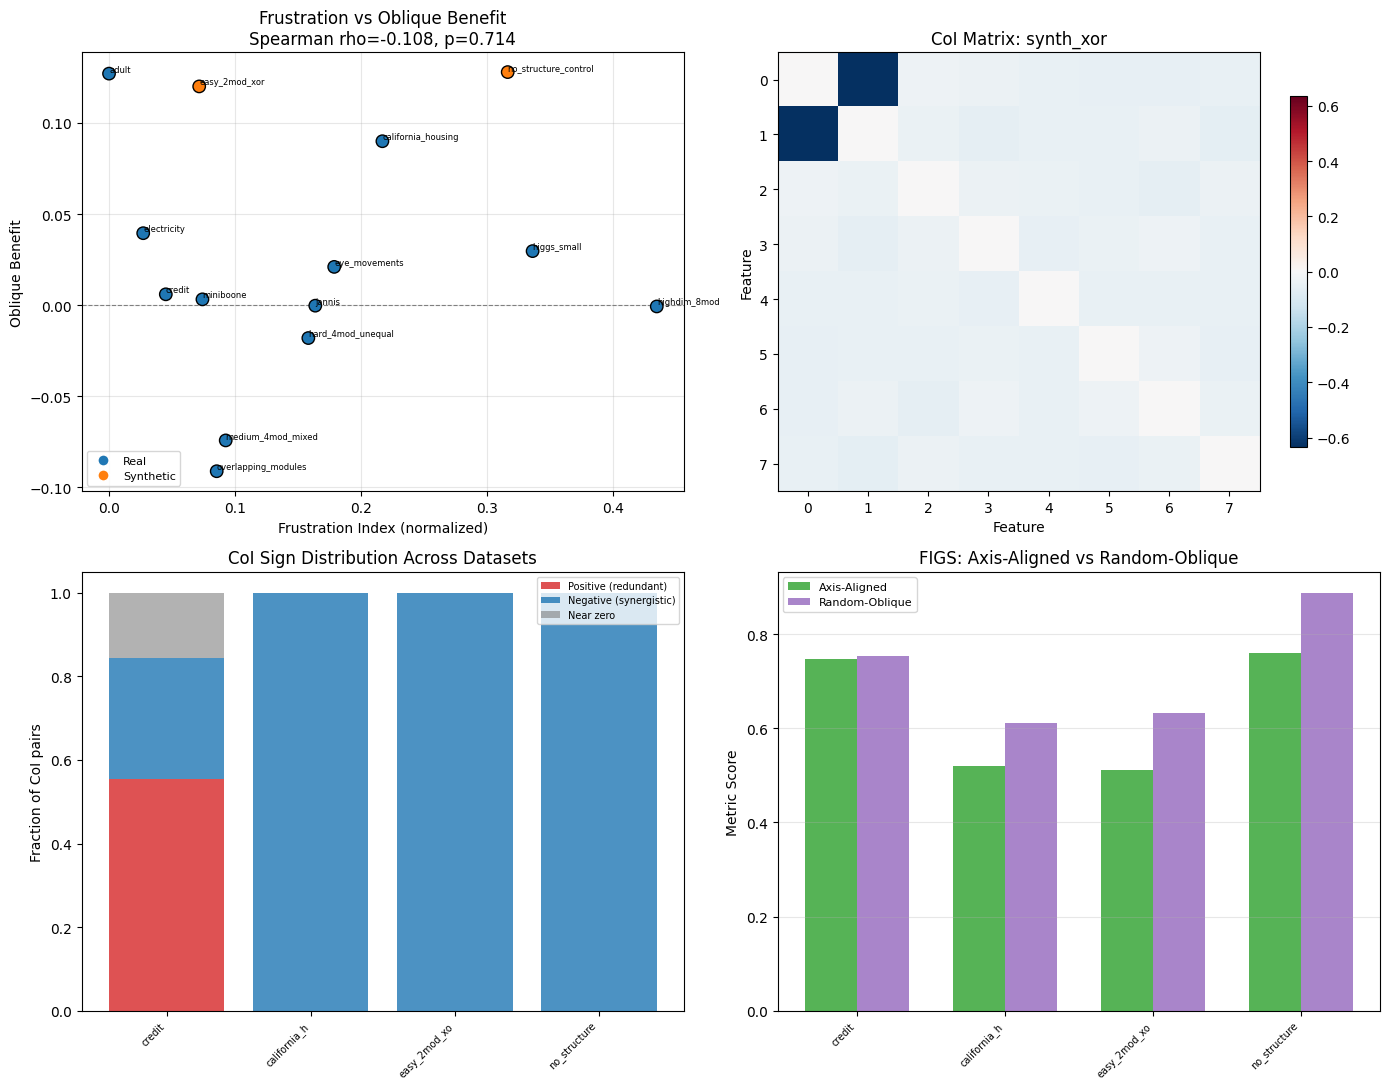

Visualization complete.


In [13]:
fig, axes = plt.subplots(2, 2, figsize=(14, 11))

# --- Panel 1: Frustration vs Oblique Benefit scatter ---
ax = axes[0, 0]
per_ds = data["metadata"]["per_dataset_results"]
is_synth = [per_ds[n].get("is_synthetic", False) if n in per_ds else False for n in names]
colors = ["tab:orange" if s else "tab:blue" for s in is_synth]
ax.scatter(frust_arr, obliq_arr, c=colors, s=80, edgecolors="k", zorder=3)
for i, nm in enumerate(names):
    ax.annotate(nm, (frust_arr[i], obliq_arr[i]), fontsize=6, ha="left", va="bottom")
ax.set_xlabel("Frustration Index (normalized)")
ax.set_ylabel("Oblique Benefit")
ax.set_title(f"Frustration vs Oblique Benefit\nSpearman rho={rho:.3f}, p={p_value:.3f}")
ax.axhline(0, color="gray", ls="--", lw=0.8)
# Legend
from matplotlib.lines import Line2D
legend_elements = [Line2D([0], [0], marker='o', color='w', markerfacecolor='tab:blue', markersize=8, label='Real'),
                   Line2D([0], [0], marker='o', color='w', markerfacecolor='tab:orange', markersize=8, label='Synthetic')]
ax.legend(handles=legend_elements, loc="best", fontsize=8)
ax.grid(True, alpha=0.3)

# --- Panel 2: CoI heatmaps for demo datasets ---
ax = axes[0, 1]
ds_names_demo = list(demo_results.keys())
coi1 = demo_results[ds_names_demo[0]]["coi_matrix"]
im = ax.imshow(coi1, cmap="RdBu_r", aspect="auto",
               vmin=-np.max(np.abs(coi1)), vmax=np.max(np.abs(coi1)))
ax.set_title(f"CoI Matrix: {ds_names_demo[0]}")
ax.set_xlabel("Feature")
ax.set_ylabel("Feature")
plt.colorbar(im, ax=ax, shrink=0.8)

# --- Panel 3: CoI sign distribution bar chart ---
ax = axes[1, 0]
subset_names = list(per_ds.keys())[:8]  # Show up to 8 datasets
frac_pos = [per_ds[n]["graph_characterization"]["sign_distribution"]["frac_positive"] for n in subset_names]
frac_neg = [per_ds[n]["graph_characterization"]["sign_distribution"]["frac_negative"] for n in subset_names]
frac_zero = [per_ds[n]["graph_characterization"]["sign_distribution"]["frac_near_zero"] for n in subset_names]
x_pos = np.arange(len(subset_names))
ax.bar(x_pos, frac_pos, label="Positive (redundant)", color="tab:red", alpha=0.8)
ax.bar(x_pos, frac_neg, bottom=frac_pos, label="Negative (synergistic)", color="tab:blue", alpha=0.8)
ax.bar(x_pos, frac_zero, bottom=[p+n for p, n in zip(frac_pos, frac_neg)], label="Near zero", color="tab:gray", alpha=0.6)
ax.set_xticks(x_pos)
ax.set_xticklabels([n[:12] for n in subset_names], rotation=45, ha="right", fontsize=7)
ax.set_ylabel("Fraction of CoI pairs")
ax.set_title("CoI Sign Distribution Across Datasets")
ax.legend(fontsize=7, loc="upper right")

# --- Panel 4: FIGS axis-aligned vs oblique comparison ---
ax = axes[1, 1]
ds_figs_names = list(per_ds.keys())[:8]
aa_vals = [per_ds[n]["figs_comparison"]["metric_axis_aligned"] for n in ds_figs_names]
ro_vals = [per_ds[n]["figs_comparison"]["metric_random_oblique"] for n in ds_figs_names]
x_pos = np.arange(len(ds_figs_names))
w = 0.35
ax.bar(x_pos - w/2, aa_vals, w, label="Axis-Aligned", color="tab:green", alpha=0.8)
ax.bar(x_pos + w/2, ro_vals, w, label="Random-Oblique", color="tab:purple", alpha=0.8)
ax.set_xticks(x_pos)
ax.set_xticklabels([n[:12] for n in ds_figs_names], rotation=45, ha="right", fontsize=7)
ax.set_ylabel("Metric Score")
ax.set_title("FIGS: Axis-Aligned vs Random-Oblique")
ax.legend(fontsize=8)
ax.grid(True, axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("demo_results.png", dpi=100, bbox_inches="tight")
plt.show()
print("Visualization complete.")